In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [10]:
df = pd.read_csv('data/train.csv')
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
df.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


In [6]:
df.groupby("Season")["Temperature_C"].mean()
# result shows that season does not imply temperature

Season
Kharif    27.026282
Rabi      26.959173
Zaid      27.008016
Name: Temperature_C, dtype: float64

In [22]:
df.groupby("Season")["Rainfall_mm"].mean()
# also implies no meaningful seasonal variation in rainfall!!!

Season
Kharif    1456.095913
Rabi      1470.786303
Zaid      1459.962673
Name: Rainfall_mm, dtype: float64

In [23]:
pd.crosstab(df["Season"], df["Irrigation_Need"], normalize="index")
# the differences in irrigation need across season are very small
# seems that season can be dropped, as it does not have.a predictive power.
# I will keep it. but I need to remember that I should test my models without it as well.

Irrigation_Need,High,Low,Medium
Season,,,
Kharif,0.034826,0.571349,0.393824
Rabi,0.032115,0.599770,0.368115
Zaid,0.033037,0.591088,0.375875


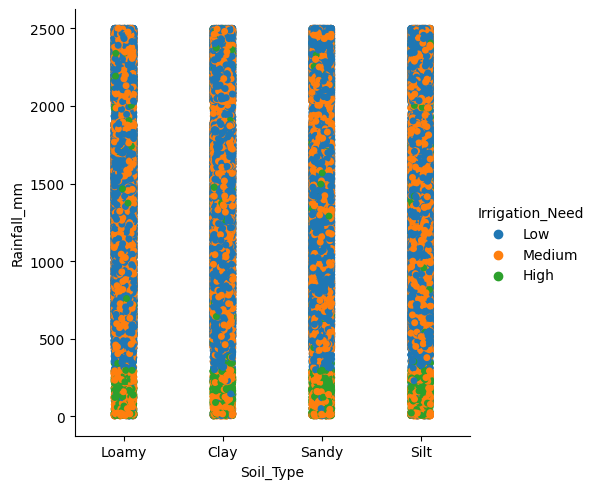

In [24]:
sns.catplot(df, x='Soil_Type', y='Rainfall_mm', hue='Irrigation_Need')

<Axes: xlabel='Soil_Type', ylabel='Soil_pH'>

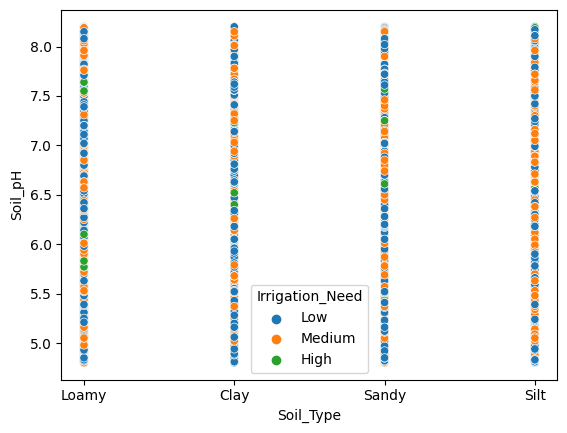

In [25]:
sns.scatterplot(df, x='Soil_Type', y='Soil_pH', hue='Irrigation_Need')

<Axes: xlabel='Irrigation_Need', ylabel='count'>

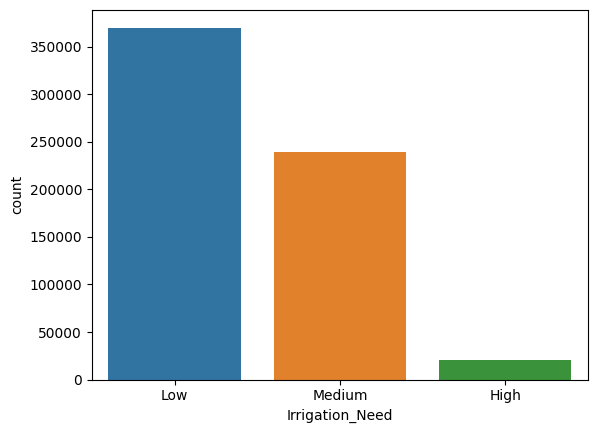

In [26]:
sns.countplot(df, x='Irrigation_Need')

Text(0.5, 1.0, 'Humidity Distribution')

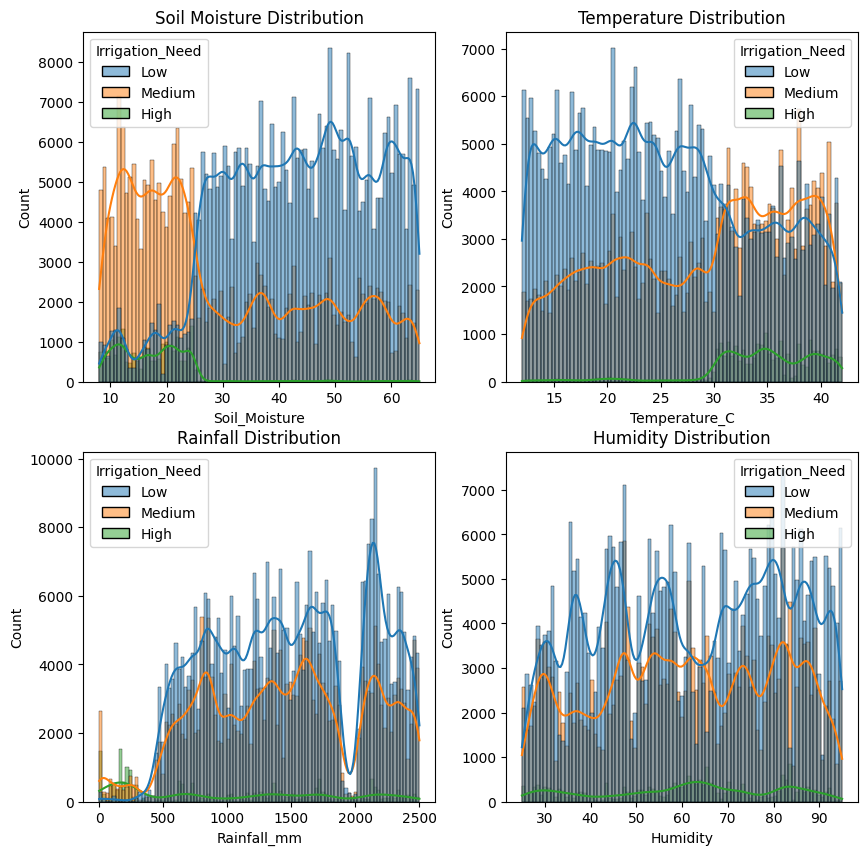

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sns.histplot(df, x='Soil_Moisture', hue='Irrigation_Need', ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Soil Moisture Distribution')

sns.histplot(df, x='Temperature_C', hue='Irrigation_Need', ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Temperature Distribution')

sns.histplot(df, x='Rainfall_mm', hue='Irrigation_Need', ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Rainfall Distribution')

sns.histplot(df, x='Humidity', hue='Irrigation_Need', ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Humidity Distribution')


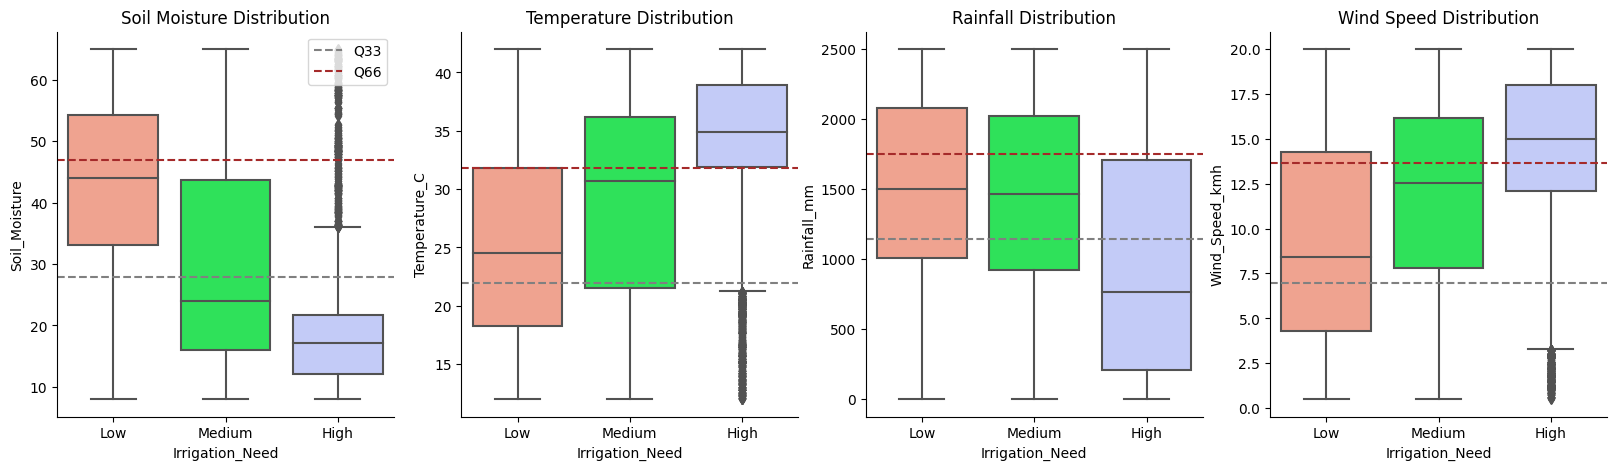

In [ ]:
rf_low, rf_high = df["Rainfall_mm"].quantile([0.33, 0.66])
sm_low, sm_high = df["Soil_Moisture"].quantile([0.33, 0.66])
temp_low, temp_high = df["Temperature_C"].quantile([0.33, 0.66])
ws_low, ws_high = df["Wind_Speed_kmh"].quantile([0.33, 0.66])

palette={'Low': '#FF9A80', 'Medium': '#11FF4A', 'High': '#BBC5FF'}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.boxplot(df, y='Soil_Moisture', x='Irrigation_Need', palette=palette, ax=axes[0])
axes[0].set_title('Soil Moisture Distribution')
axes[0].axhline(sm_low, color='gray', linestyle='--', label='Q33')
axes[0].axhline(sm_high, color='brown', linestyle='--', label='Q66')
axes[0].legend(loc='upper right')
sns.despine()

sns.boxplot(df, y='Temperature_C', x='Irrigation_Need', palette=palette, ax=axes[1])
axes[1].set_title('Temperature Distribution')
axes[1].axhline(temp_low, color='gray', linestyle='--')
axes[1].axhline(temp_high, color='brown', linestyle='--')

sns.boxplot(df, y='Rainfall_mm',x='Irrigation_Need', palette=palette, ax=axes[2])
axes[2].set_title('Rainfall Distribution')
axes[2].axhline(rf_low, color='gray', linestyle='--')
axes[2].axhline(rf_high, color='brown', linestyle='--')

sns.boxplot(df, y='Wind_Speed_kmh', x='Irrigation_Need', palette=palette, ax=axes[3])
axes[3].set_title('Wind Speed Distribution')
axes[3].axhline(ws_low, color='gray', linestyle='--')
axes[3].axhline(ws_high, color='brown', linestyle='--')


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

Text(0.5, 1.0, 'Previous Irrigation Distribution')

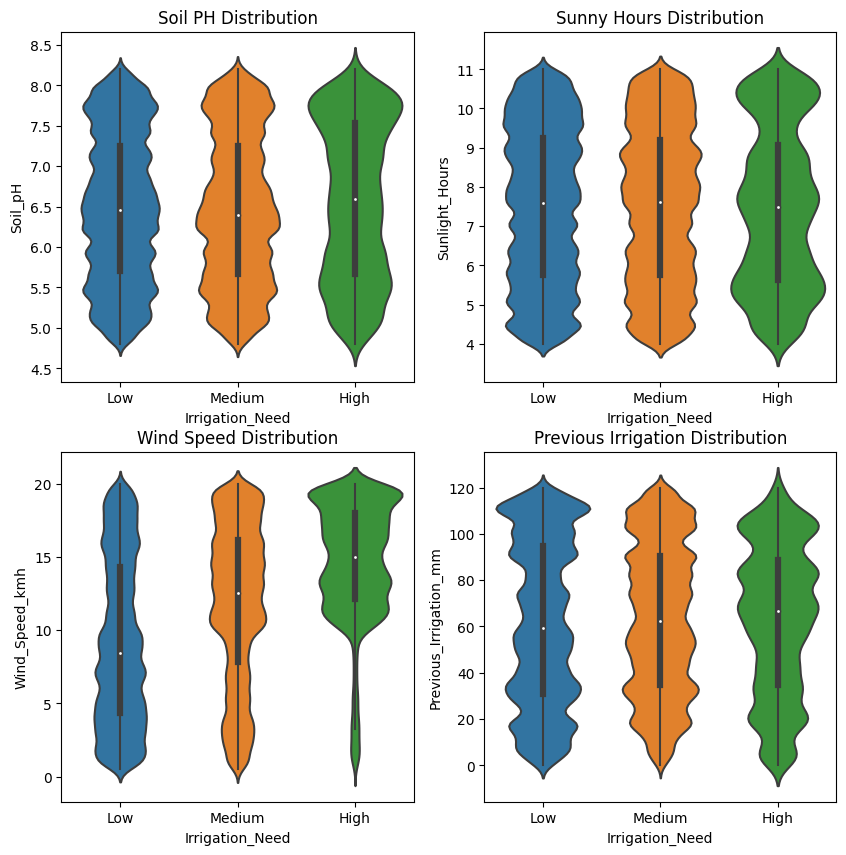

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sns.violinplot(df, y='Soil_pH', x='Irrigation_Need', ax=axes[0, 0])
axes[0, 0].set_title('Soil PH Distribution')

sns.violinplot(df, y='Sunlight_Hours', x='Irrigation_Need', ax=axes[0, 1])
axes[0, 1].set_title('Sunny Hours Distribution')

sns.violinplot(df, y='Wind_Speed_kmh',x='Irrigation_Need', ax=axes[1, 0])
axes[1, 0].set_title('Wind Speed Distribution')

sns.violinplot(df, y='Previous_Irrigation_mm', x='Irrigation_Need', ax=axes[1, 1])
axes[1, 1].set_title('Previous Irrigation Distribution')

In [31]:
cat_columns = df.select_dtypes(include=["object"]).columns
num_columns = df.select_dtypes(include=["int64", "float64"]).columns
print(num_columns)

Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm'],
      dtype='object')


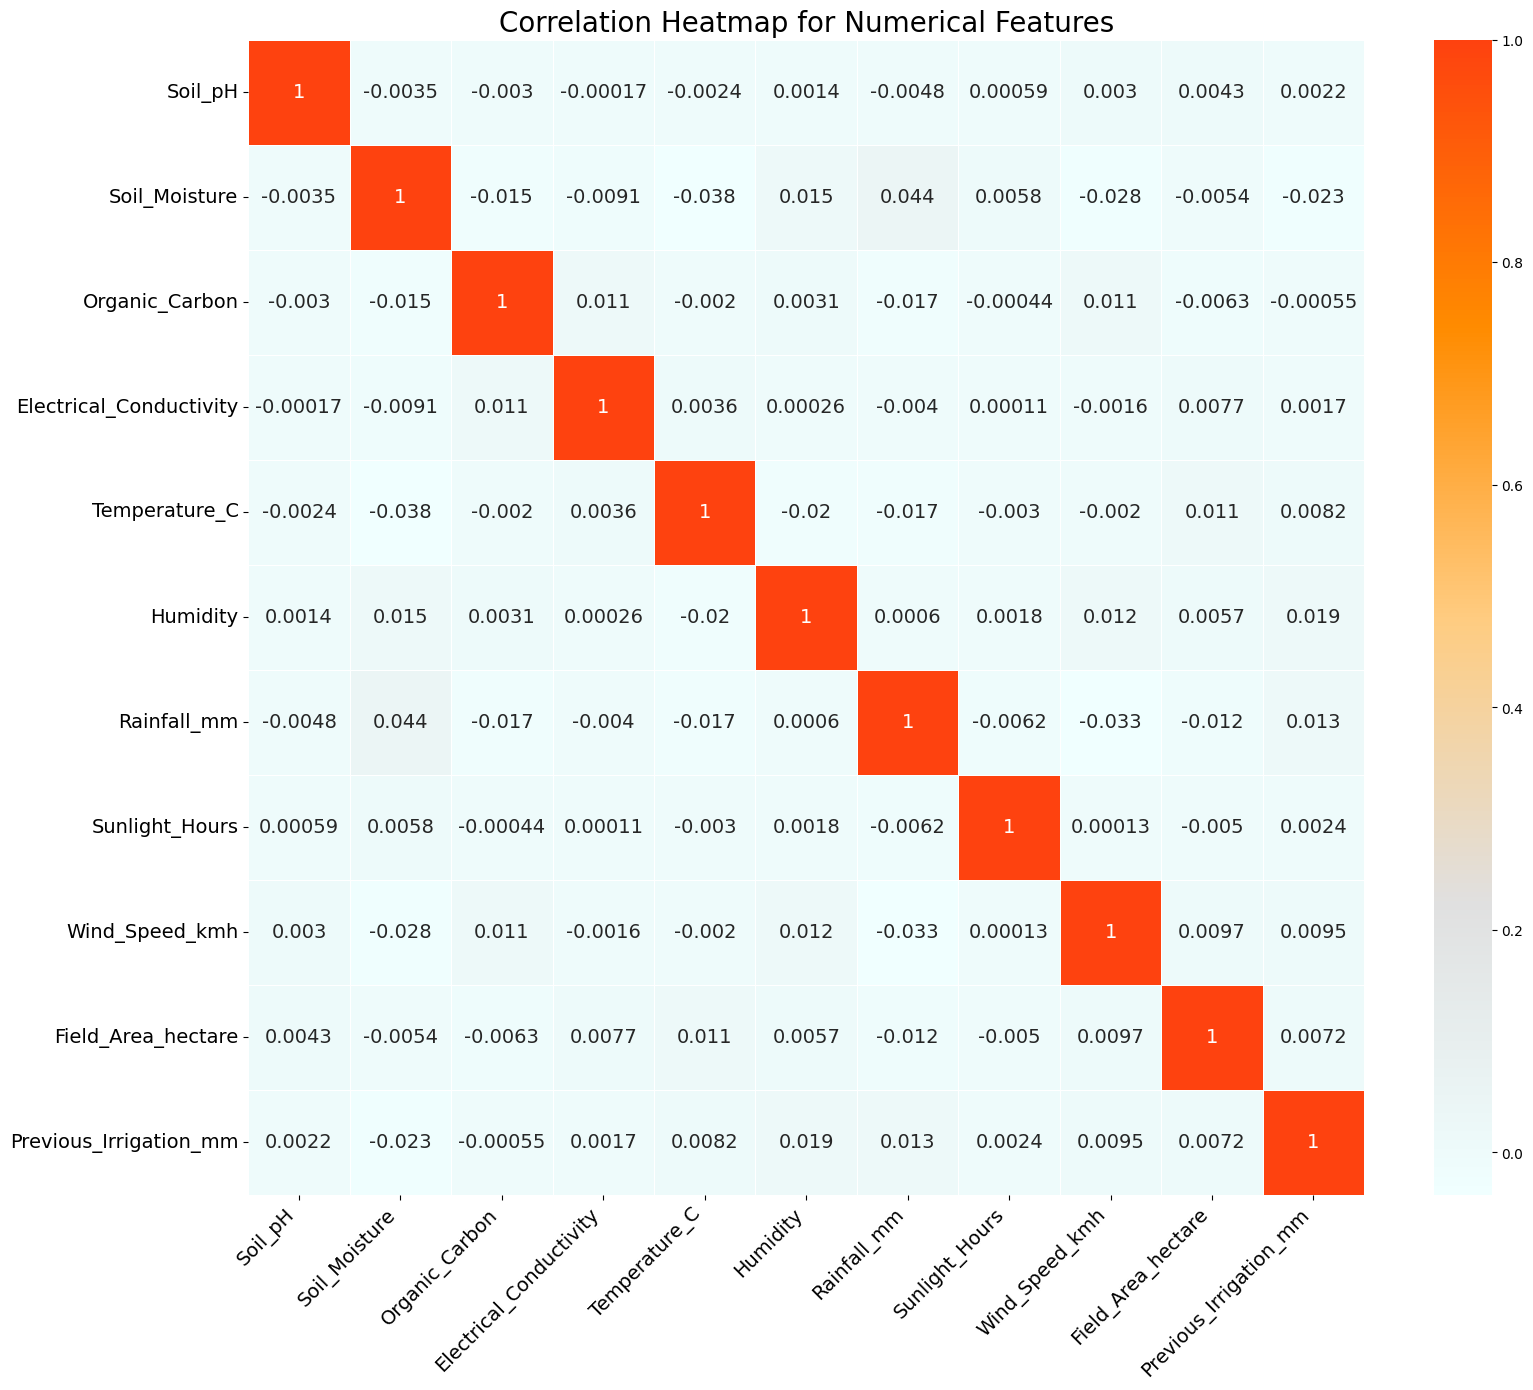

In [15]:
df1 = df.drop('id', axis=1)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "gray_to_orange",
    ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)

num_features = df1.select_dtypes(include=["int64", "float64"])
cat_features = df1.select_dtypes(include=["object"])

corr = num_features.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(corr, annot=True, cmap=cmap, linewidths=0.5, annot_kws={"size": 14})
plt.title("Correlation Heatmap for Numerical Features", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14)
plt.show()

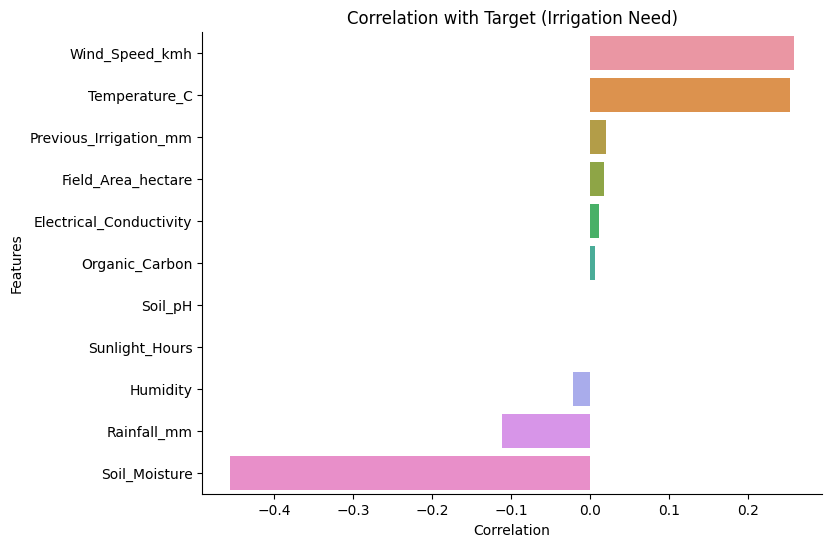

In [33]:
df_corr = df.drop(columns=["id"])

mapping = {"Low": 0, "Medium": 1, "High": 2}
df_corr["Irrigation_Need_Encoded"] = df_corr["Irrigation_Need"].map(mapping)

# correlatio with target
corr_target = df_corr.corr(numeric_only=True)["Irrigation_Need_Encoded"].sort_values(ascending=False)
corr_target = corr_target.drop("Irrigation_Need_Encoded")

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_target.values, y=corr_target.index)
sns.despine()
plt.title("Correlation with Target (Irrigation Need)")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

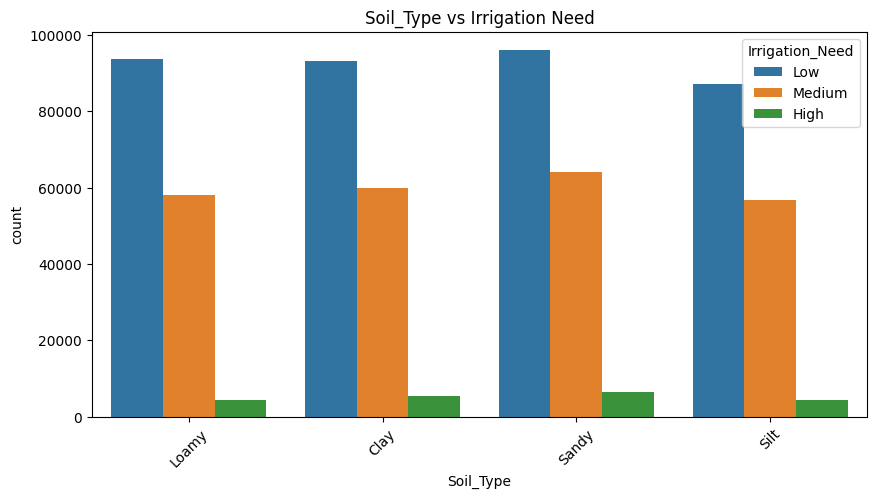

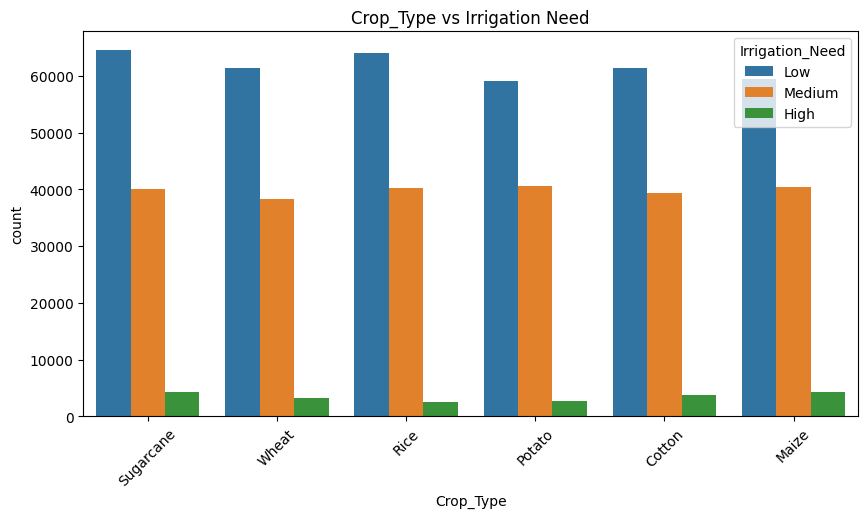

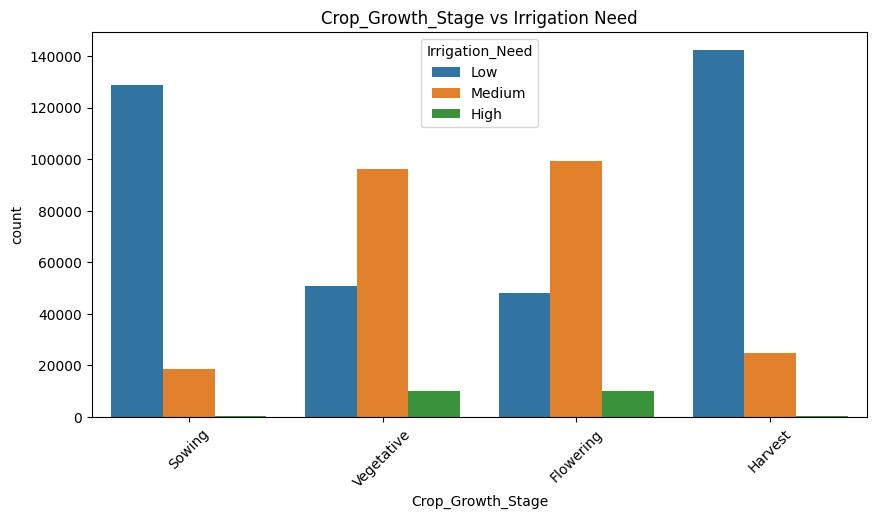

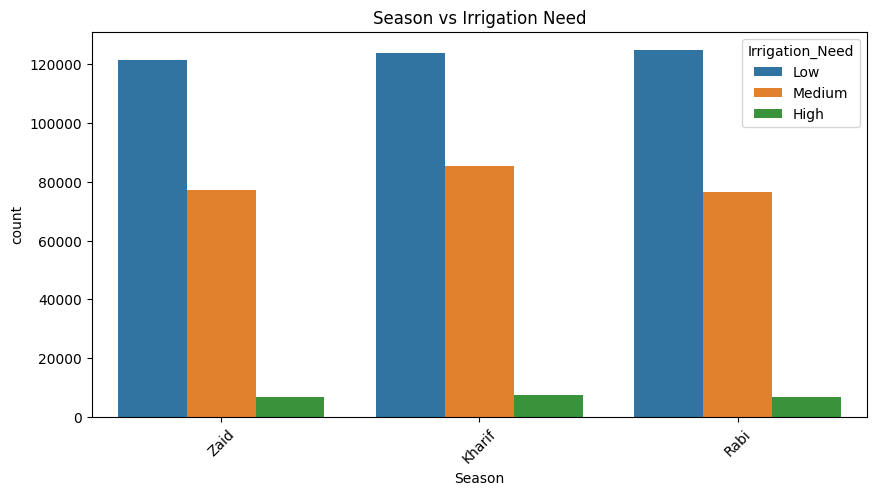

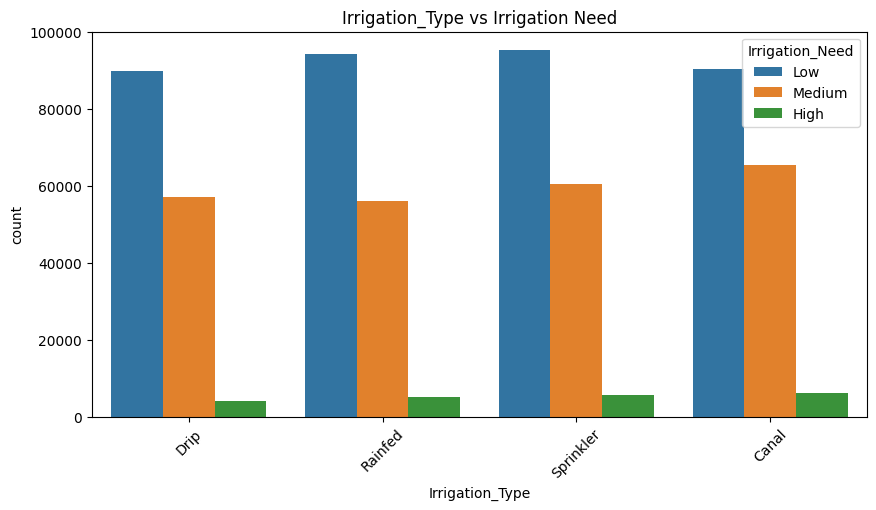

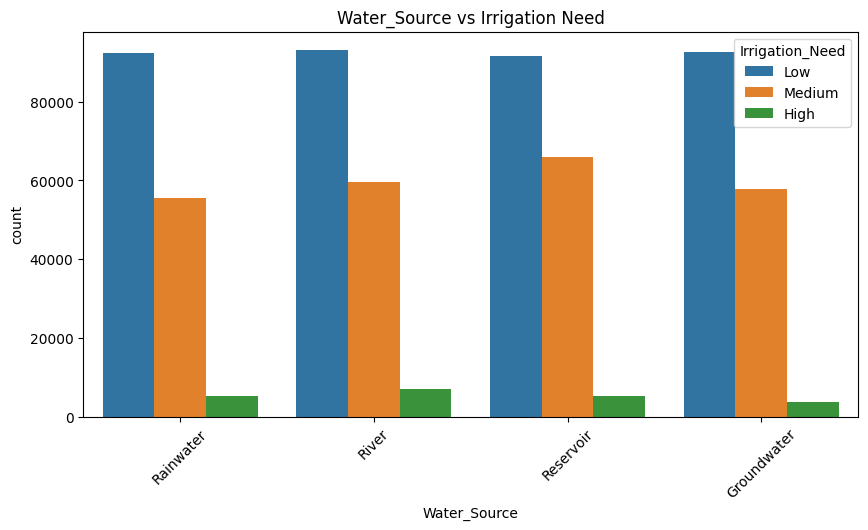

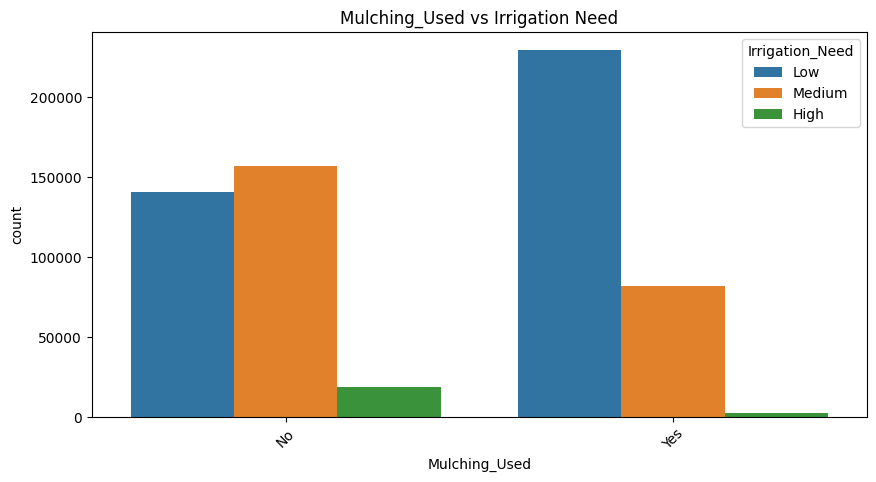

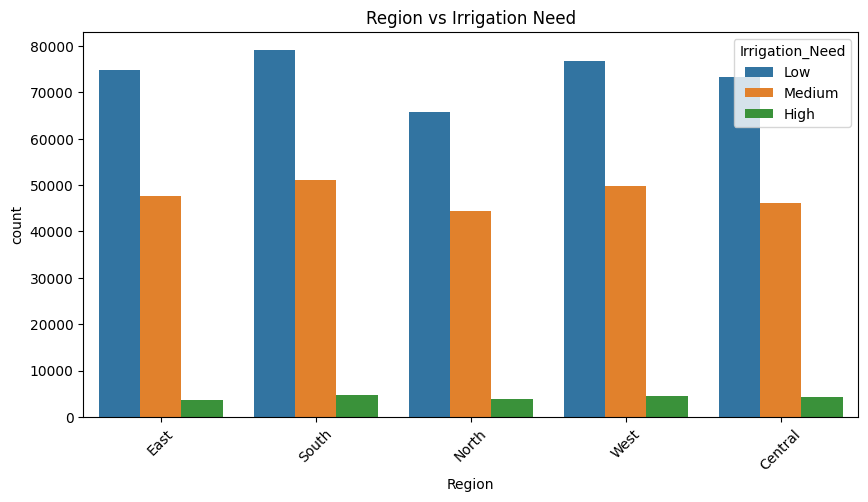

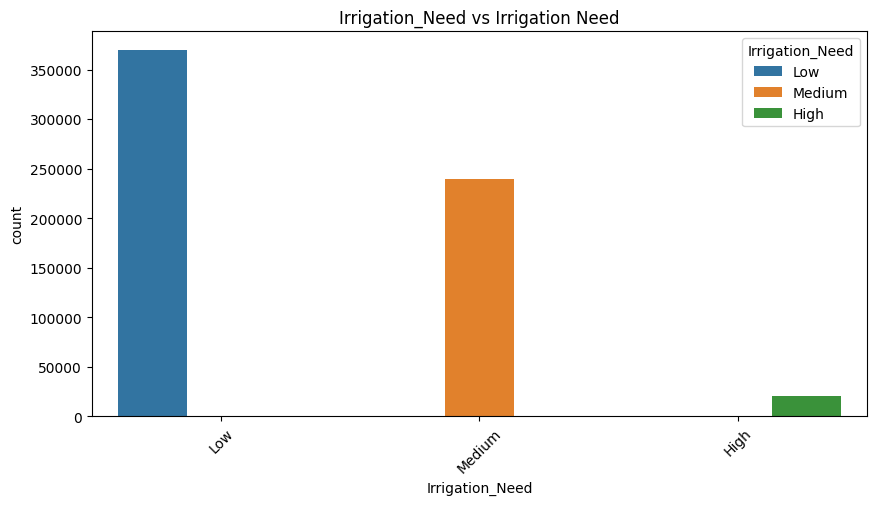

In [34]:
for col in cat_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue="Irrigation_Need")
    plt.title(f"{col} vs Irrigation Need")
    plt.xticks(rotation=45)
    plt.show()

Text(0, 0.5, 'humidity')

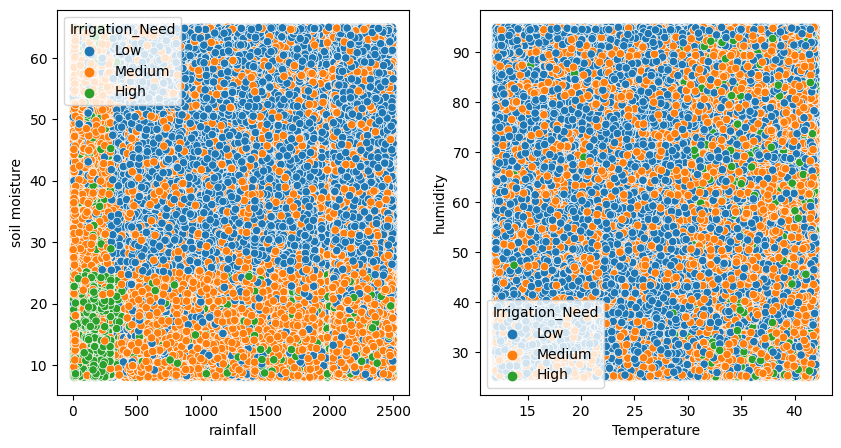

In [35]:


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(df, x='Rainfall_mm', y='Soil_Moisture', hue='Irrigation_Need', ax=axes[0])
axes[0].set_xlabel('rainfall')
axes[0].set_ylabel('soil moisture')

sns.scatterplot(df, x='Temperature_C', y='Humidity', hue='Irrigation_Need', ax=axes[1])
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('humidity')

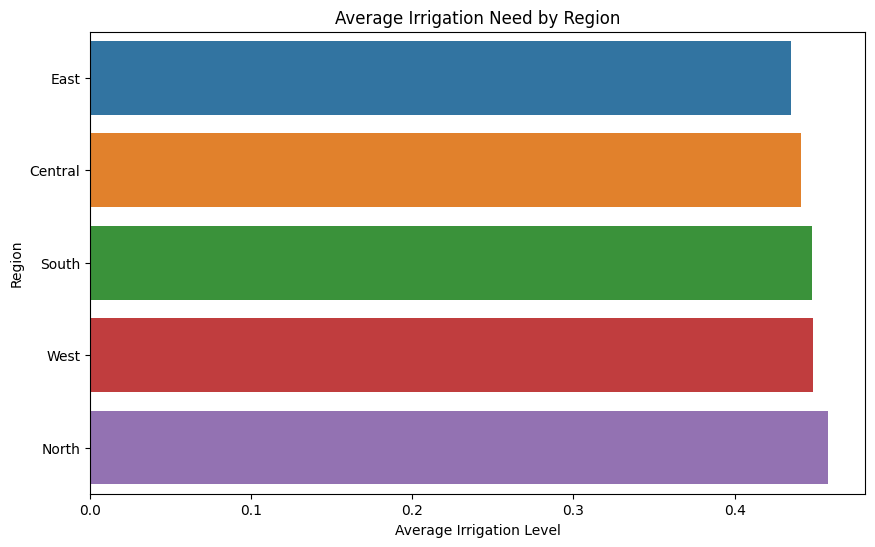

In [39]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
df["Irrigation_Need_Encoded"] = df["Irrigation_Need"].map(mapping)

region_irrigation = df.groupby("Region")["Irrigation_Need_Encoded"].mean().sort_values()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=region_irrigation.values, y=region_irrigation.index)

plt.title("Average Irrigation Need by Region")
plt.xlabel("Average Irrigation Level")
plt.ylabel("Region")

plt.show()

<Axes: xlabel='Crop_Growth_Stage', ylabel='count'>

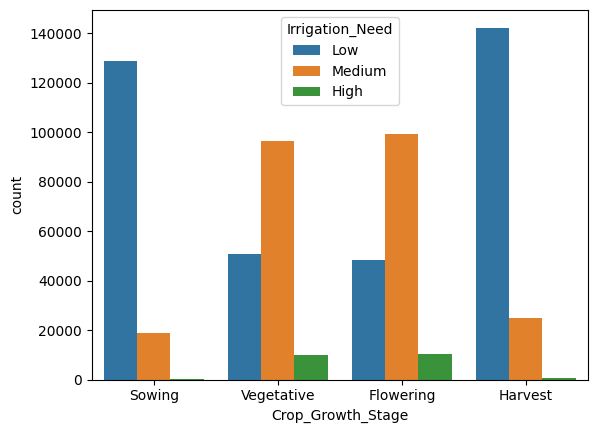

In [37]:
sns.countplot(data=df, x="Crop_Growth_Stage", hue="Irrigation_Need")

In [41]:
cat_columns.drop('Irrigation_Need')

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
      dtype='object')

### Feature importance (to decide on which features should be kept, which dropped)

Text(0, 0.5, 'Feature')

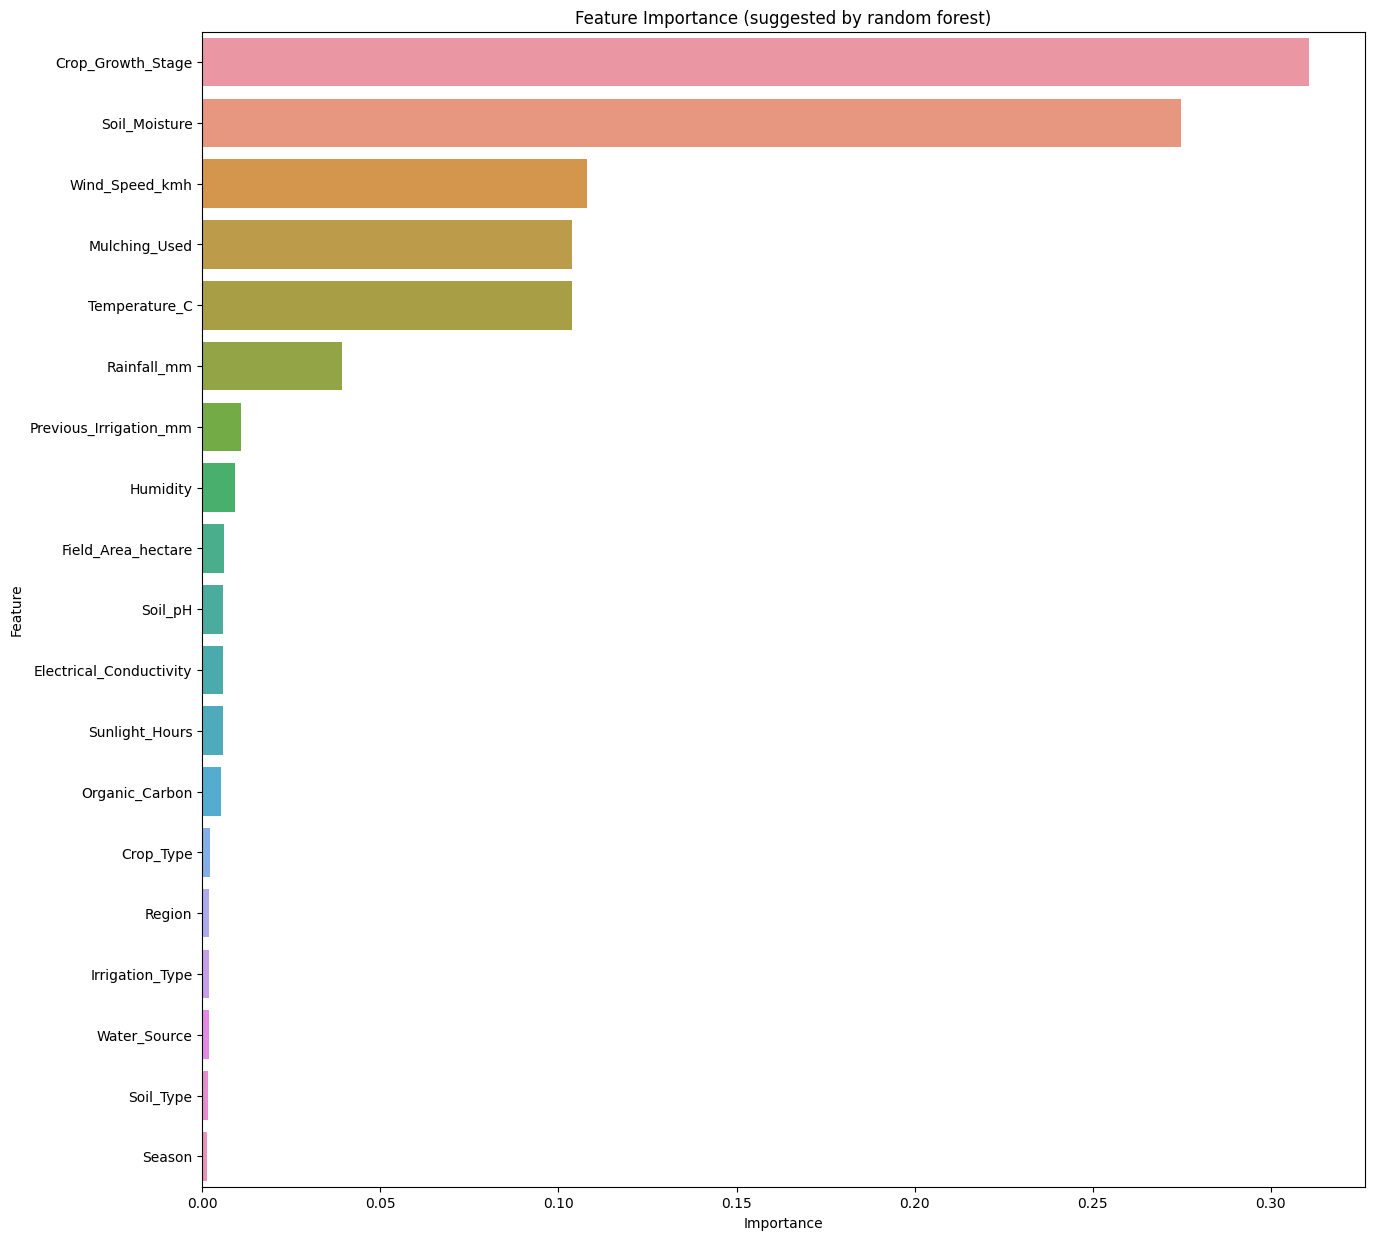

In [42]:
# get important features by random forest model

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df_train = df.copy()
cat_columns = df_train.select_dtypes(include=["object"]).columns

for col in cat_columns.drop('Irrigation_Need'):
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])

X = df_train.drop(["Irrigation_Need_Encoded", "Irrigation_Need", "id"], axis=1)
y = df_train["Irrigation_Need_Encoded"]

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=50,
    n_jobs=-1
)

rf.fit(X, y)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(15, 15))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (suggested by random forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")


In [44]:
print(feature_importance[feature_importance["Feature"] == "Humidity"])

    Feature  Importance
6  Humidity    0.009235


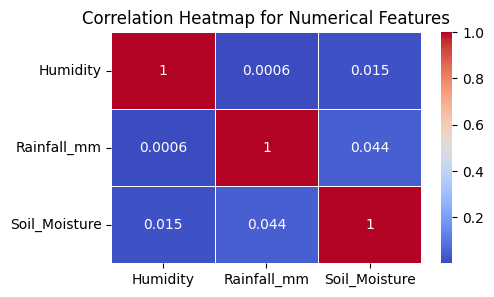

In [45]:
# it is strange that humidity plays such an unimportant role in irrigation need. 
# so I need to check closely if there is a correlations between this and several other feathers?
corr = df[["Humidity", "Rainfall_mm", "Soil_Moisture"]].corr()
#print(corr)
plt.figure(figsize=(5, 3))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

my speculation was not correct.

seems that irrigation depends more directly on:

Soil moisture and Rainfall

Humidity is less direct

Text(0, 0.5, 'Feature')

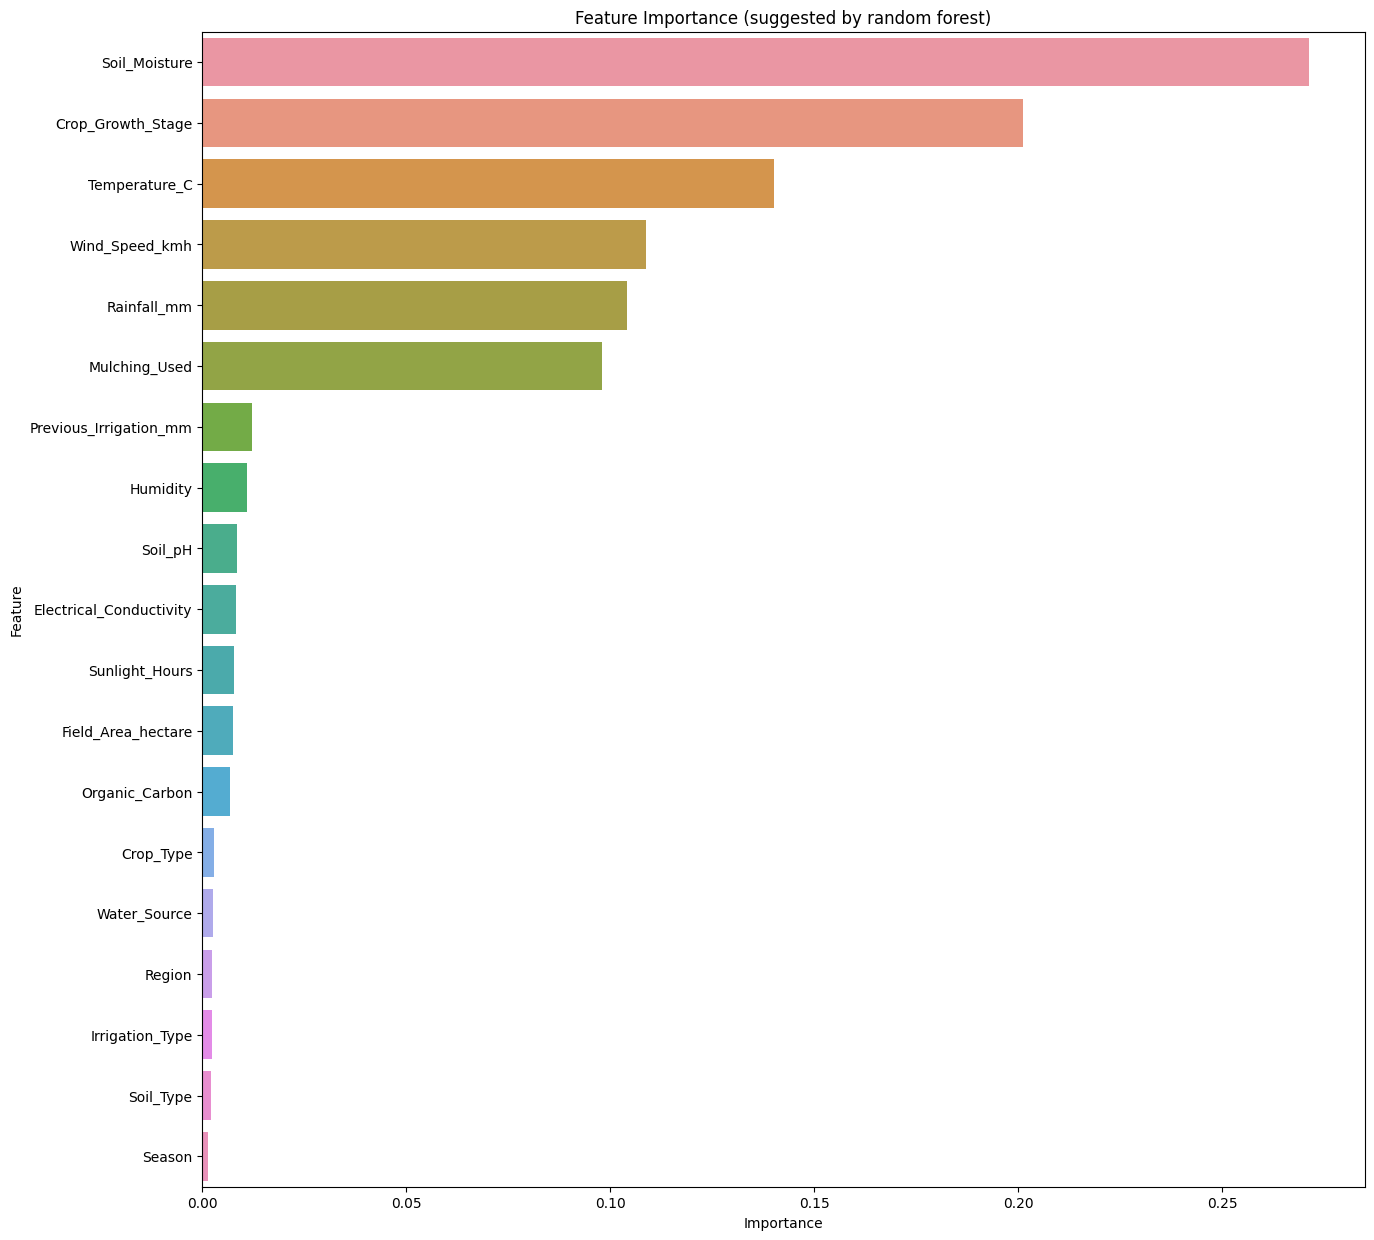

In [46]:
# now I am making balance between three classes of irrigation need to check if it improve feature importance

df_train = df.copy()
cat_columns = df_train.select_dtypes(include=["object"]).columns

for col in cat_columns.drop('Irrigation_Need'):
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])

X = df_train.drop(["Irrigation_Need_Encoded", "Irrigation_Need", "id"], axis=1)
y = df_train["Irrigation_Need_Encoded"]

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=50,
    n_jobs=-1
)

rf.fit(X, y)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(15, 15))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (suggested by random forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

In [47]:
print(feature_importance[feature_importance["Feature"] == "Humidity"])
# now humidity is more important!

    Feature  Importance
6  Humidity    0.010915


In [48]:
df['Soil_Type'].unique()

array(['Loamy', 'Clay', 'Sandy', 'Silt'], dtype=object)

In [49]:
df_train = df.copy()
cat_columns

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object')

In [50]:
# there are so many non-ordinal categorical features. 
# Therefore, OneHotEncode would better fit to encode those:

from sklearn.preprocessing import OneHotEncoder

df_train = df.copy()

df_train = df_train.drop(["Irrigation_Need_Encoded", "id"], axis=1)

cat_columns = df_train.select_dtypes(include="object").columns
cat_columns = [col for col in cat_columns if col != "Irrigation_Need"]

num_columns = df_train.select_dtypes(include=["int64", "float64"]).columns

ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")

X_cat = ohe.fit_transform(df_train[cat_columns])
X_num = df_train[num_columns].values

X = np.hstack([X_num, X_cat])
y = df["Irrigation_Need"]

ohe_feature_names = ohe.get_feature_names_out(cat_columns)
feature_names = list(num_columns) + list(ohe_feature_names)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=50,
    n_jobs=-1
)

rf.fit(X, y)


/Users/hedyeh/Ginger_Gradient/ds-ml-project/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=50)

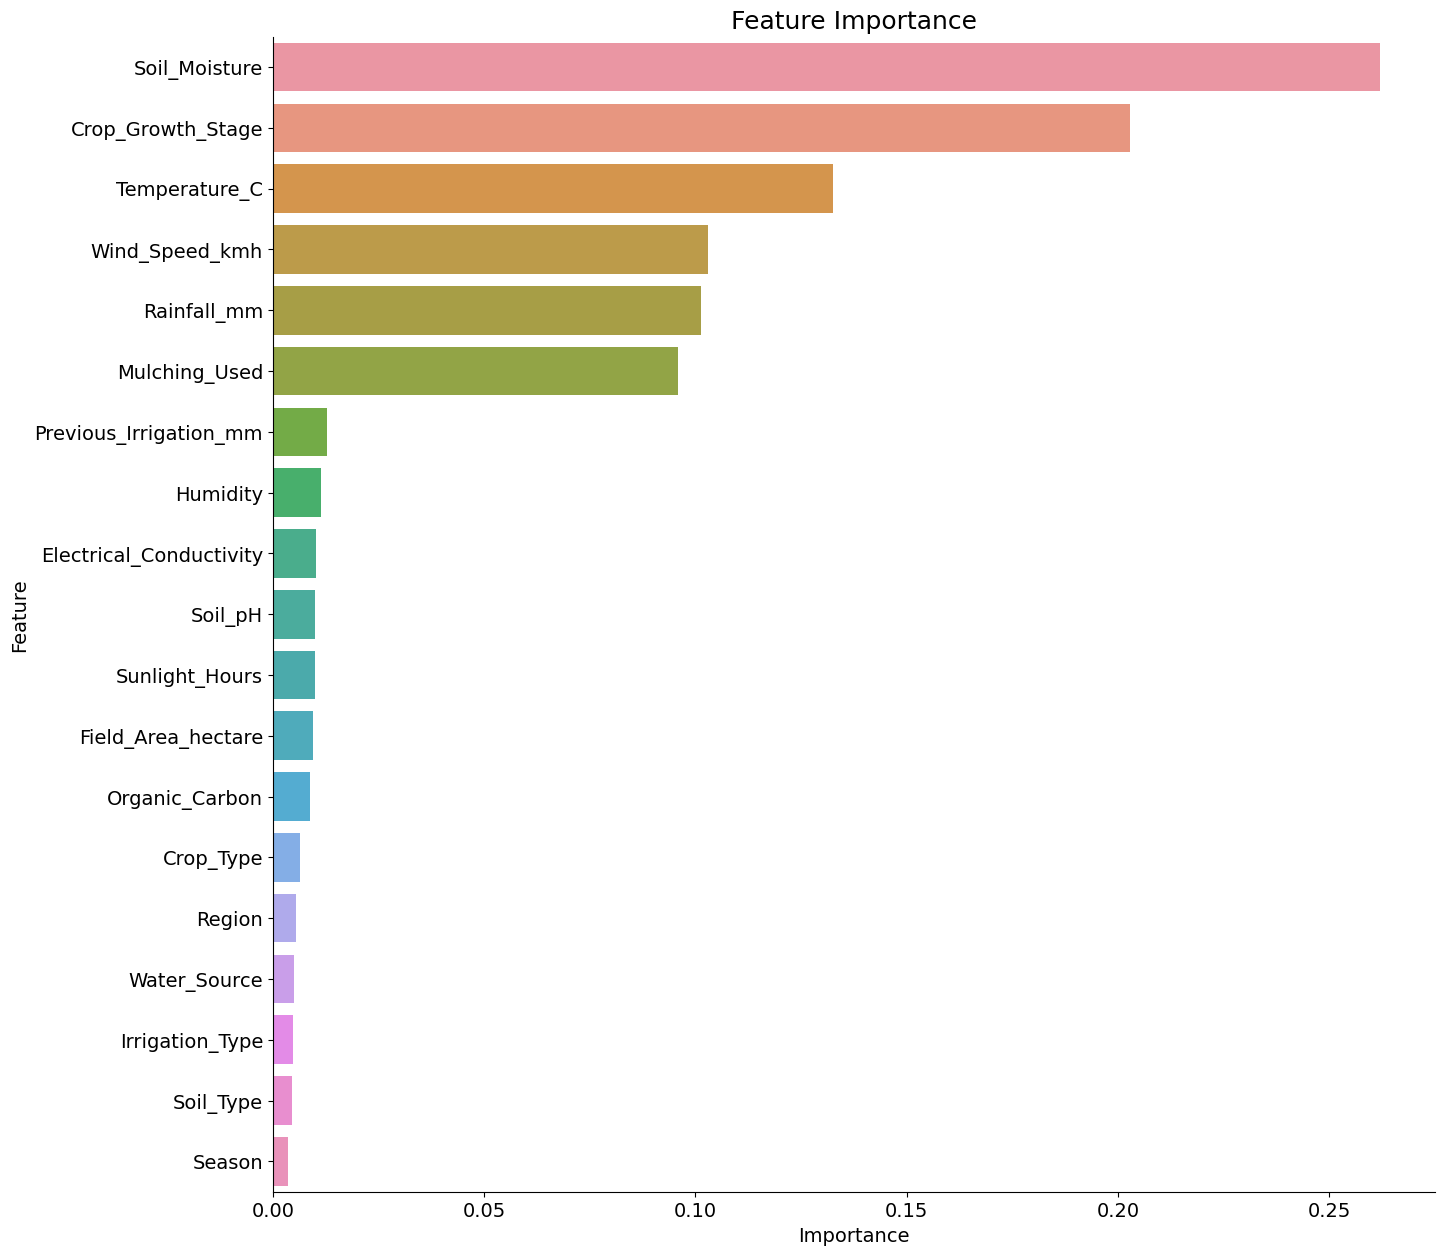

In [56]:
# now I need to group OneHotEncode columns back to original feature names

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance["Original_Feature"] = feature_importance["Feature"].apply(
    lambda x: x.rsplit("_", 1)[0] if x not in num_columns else x
)

agg_importance = feature_importance.groupby("Original_Feature")["Importance"].sum() \
                                  .sort_values(ascending=False) \
                                  .reset_index()

plt.figure(figsize=(15, 15))

sns.barplot(
    data=agg_importance,
    x="Importance",
    y="Original_Feature"
)
plt.title("Feature Importance", fontsize=18)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
sns.despine()


Seems that regardless of which method we take for the encoding, all featured more or less play a role in Irrigation-Need. So we decided to keep all features.